In [438]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn import linear_model 

In [439]:
df = pd.read_excel('home_prices.xlsx')
df

,area,price
0,2600,550000
1,3000,565000
2,3200,610000
3,3600,680000
4,4000,725000


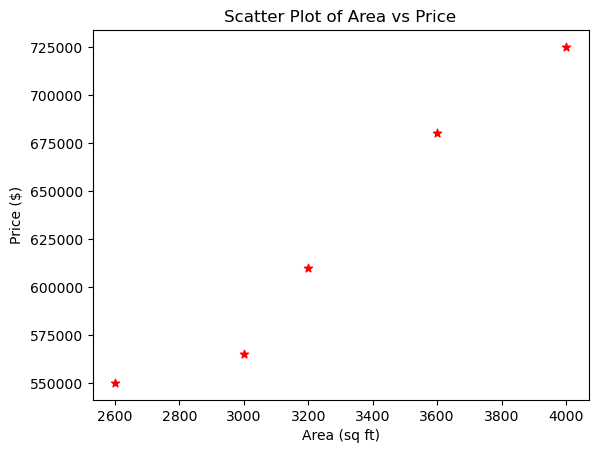

In [440]:
# Scatter plot
plt.scatter(df.area, df.price, color='red', marker='*')
plt.xlabel("Area (sq ft)")
plt.ylabel("Price ($)")
plt.title("Scatter Plot of Area vs Price")
plt.show()

In [441]:
# Train model
regression = linear_model.LinearRegression()
regression.fit(df[['area']], df.price)  # Fit using a DataFrame column

LinearRegression()

In [442]:
# # Predict correctly
# prediction = regression.predict(pd.DataFrame([[3300]], columns=['area']))
# print("Predicted Price:", prediction[0])

### Prediction

In [443]:
# Correct way to predict: Pass a DataFrame
new_area = pd.DataFrame({'area': [3300]})  # Create a DataFrame
predicted_price = regression.predict(new_area)  # =============Predict here==============
print(f"Predicted price for 3300 sq ft: {predicted_price[0]}")

x = new_area['area'][0]   # independent variable

Predicted price for 3300 sq ft: 628715.7534246575


In [444]:
# Accessing the coefficient (good practice)
print(f"Intercept: {regression.intercept_}")
print(f"Coefficient/slope/Gradient/Rate of changes (m): {regression.coef_}")

b = regression.intercept_  # intercept, b | w0
m = regression.coef_[0]    # Coefficient/slope/Gradient/Rate of changes, m

Intercept: 180616.43835616432
Coefficient/slope/Gradient/Rate of changes (m): [135.78767123]


In [445]:
# # For multiple predictions:
# new_areas = pd.DataFrame({'area': [3300, 4500, 5000]})
# predicted_prices = regression.predict(new_areas)
# print(f"Predicted prices: {predicted_prices}")

In [446]:
# # Accessing the coefficients (good practice)
# print(f"Intercept: {regression.intercept_}")
# print(f"Coefficient/slope/Gradient/Rate of changes (m): {regression.coef_[0]}")

### Calculation

In [447]:
# Calculate the dependent variable y using the linear equation
y = m * x + b

# Output the result
print(f"For input x = {x}, m = {m} , b = {b}  the output dependent variable y = {y}")

For input x = 3300, m = 135.78767123287673 , b = 180616.43835616432  the output dependent variable y = 628715.7534246575


### ==========================Process & Store into an excel file==================================

In [448]:
df = pd.read_excel('data_to_predict.xlsx')
df.head(2)

,area
0,2600
1,3000


In [449]:
p = regression.predict(df)
df["prices"] = p
df.head(2)

,area,prices
0,2600,533664.383562
1,3000,587979.452055


### Visualize

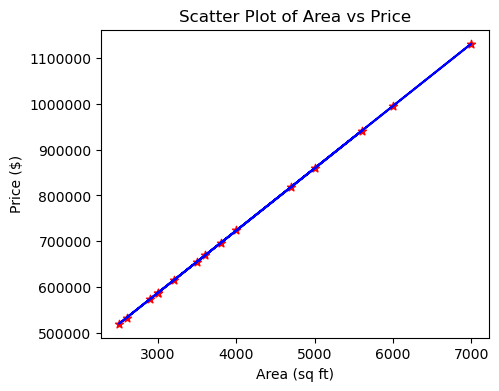

In [456]:
# Set a smaller figure size
plt.figure(figsize=(5, 4))  # Width=5, Height=3 inches
# Scatter plot
plt.xlabel("Area (sq ft)")
plt.ylabel("Price ($)")
plt.title("Scatter Plot of Area vs Price")
plt.scatter(df.area, df.prices, color='red', marker='*')
plt.plot(df.area, regression.predict(df[['area']]), color='blue')

# Ensure Y-axis shows only full numbers (disable scientific notation)
ax = plt.gca()  # Get current axis
formatter = mticker.ScalarFormatter(useOffset=False, useMathText=False)
formatter.set_scientific(False)  # Completely disable scientific notation
ax.yaxis.set_major_formatter(formatter)

plt.show()

### Store into file

In [451]:
df.to_excel('prediction.xlsx', index=False);